# Results & analysis — reversible 20M-param LLM, 50M tokens

Every number and figure below is computed **from the run artifacts committed in this repo**
(`runs/*/metrics.json`, `runs/*/curve.npy`, `runs/clocks_*.log`, `runs/*.json`).
Nothing is hard-coded, so re-running this notebook re-derives the whole report from the raw logs.

- Hardware: NVIDIA RTX 3060 **Laptop**, 6 GB (~5120 MB actually free), PyTorch 2.10.0+cu126, bf16 autocast.
- Model (identical param count for every arch): d_model 512, 6 blocks, 8 heads, MLP 4x, RoPE,
  tied embeddings, vocab 8192, seq 512 -> **23.08M params**.
- Data: one FineWeb-Edu parquet shard, byte-level BPE (8192), 52M train / 5M val tokens as uint16 memmaps.

**Contents**
1. The three required runs
2. Loss curves
3. Which reversible variant, and the LR sweep behind the choice
4. Pushing to the maximum batch
5. Throughput, and the thermal confound on a laptop GPU
6. Correctness of the reversible backward
7. Windows-specific memory traps

This notebook needs only `numpy`, `pandas`, `matplotlib` — **no GPU**. The training notebook is
[`01_colab_train_50M.ipynb`](01_colab_train_50M.ipynb); the gradient checks are in
[`03_gradient_correctness.ipynb`](03_gradient_correctness.ipynb).

In [1]:
import json, os, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# run from anywhere: repo root is wherever runs/ lives
ROOT = Path.cwd()
if not (ROOT / "runs").exists():
    ROOT = ROOT.parent
RUNS = ROOT / "runs"
assert RUNS.exists(), ROOT

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
                     "font.size": 9, "axes.titlesize": 10})
pd.set_option("display.width", 160)


def metrics(name):
    p = RUNS / name / "metrics.json"
    return json.loads(p.read_text()) if p.exists() else None


def curve(name):
    p = RUNS / name / "curve.npy"
    return np.load(p) if p.exists() else None


all_runs = sorted(d.name for d in RUNS.iterdir() if (d / "metrics.json").exists())
print(f"repo root: {ROOT}")
print(f"{len(all_runs)} runs with metrics.json\n")
print("\n".join(all_runs))

repo root: C:\Users\Monisha Srivastava\.zcode\workspace\default\reversible-20m
46 runs with metrics.json

buggy_r2_rev_euler_b16
buggy_r3_rev_euler_b192_lr1.2e-2
buggy_r3_rev_euler_b192_lr2.4e-2
buggy_s2_rev_euler_0.0015
buggy_s2_rev_euler_0.003
buggy_s2_rev_euler_0.006
buggy_s2_rev_mid_0.0015
buggy_s2_rev_mid_0.003
buggy_s2_rev_mid_0.006
g1_baseline_b16
g2_rev_mid_b16
g3_rev_mid_b192
guardtest
lr_baseline_0.003
lr_baseline_0.006
lr_rev_euler_0.006
lr_rev_euler_0.012
lr_rev_mid_0.003
lr_rev_mid_0.006
lr_rev_mid_0.012
pilot_base
pilot_euler
pilot_mid
r1_baseline_b16
r1b_baseline_b16_lr0.00075
r2_rev_mid_b16
r3_rev_mid_b192_lr0.00065
r3_rev_mid_b192_lr0.0013
r3_rev_mid_b192_lr0.0026
r3_rev_mid_b192_lr0.0052
rev_mid_b16
s2_baseline_0.003
s3_baseline_0.0002
s3_baseline_0.0004
s3_baseline_0.00075
s3_baseline_0.0015
s3_rev_euler_0.0002
s3_rev_euler_0.0004
s3_rev_euler_0.00075
s3_rev_euler_0.0015
s3_rev_euler_0.003
s3_rev_euler_0.006
s3_rev_mid_0.0004
s3_rev_mid_0.00075
s3_rev_mid_0.0015
s3_r

## 1. The three required runs

| # | what | arch | batch |
|---|---|---|---|
| 1 | baseline, fixed batch | standard pre-norm transformer | 16 |
| 2 | + reversibility, same batch | `rev_mid` (leapfrog midpoint) | 16 |
| 3 | + reversibility, max batch that fits 6 GB | `rev_mid` | 192 |

All three consume the same ~50M-token budget, each at its **own tuned LR** (see §3) — a comparison
at one shared LR would have been meaningless here (§6, last block).

In [2]:
MAIN = {
    "1. baseline b=16":        "r1b_baseline_b16_lr0.00075",
    "2. rev_mid b=16":        "r2_rev_mid_b16",
    "3. rev_mid b=192 (max)": "r3_rev_mid_b192_lr0.0013",
    "(ref) baseline b=16, mistuned lr 3e-3": "r1_baseline_b16",
}

rows = []
for label, name in MAIN.items():
    m = metrics(name)
    rows.append({
        "run": label, "arch": m["arch"], "batch": m["batch"], "lr": m["lr"],
        "steps": m["steps"], "tokens": f"{m['tokens']/1e6:.1f}M",
        "val_loss": round(m["final_val_loss"], 4), "val_ppl": round(m["val_ppl"], 1),
        "tok/s": f"{m['tokens_per_s']/1e3:.1f}k",
        "peak_alloc_MB": round(m["peak_mem_allocated_mb"]),
        "peak_resv_MB": round(m["peak_mem_reserved_mb"]),
        "wall_min": round(m["wall_s"] / 60, 1),
    })
main_df = pd.DataFrame(rows).set_index("run")
main_df

,arch,batch,lr,steps,tokens,val_loss,val_ppl,tok/s,peak_alloc_MB,peak_resv_MB,wall_min
run,,,,,,,,,,,
1. baseline b=16,baseline,16,0.00075,6103,50.0M,3.7827,43.9,40.5k,2130,2348,20.6
2. rev_mid b=16,rev_mid,16,0.00075,6103,50.0M,3.7968,44.6,28.8k,1157,1482,28.9
3. rev_mid b=192 (max),rev_mid,192,0.00130,508,49.9M,4.2545,70.4,35.2k,4502,5118,23.6
"(ref) baseline b=16, mistuned lr 3e-3",baseline,16,0.00300,6103,50.0M,4.1503,63.5,33.8k,2130,2348,24.7


In [3]:
b  = metrics(MAIN["1. baseline b=16"])
r  = metrics(MAIN["2. rev_mid b=16"])
r3 = metrics(MAIN["3. rev_mid b=192 (max)"])

P = b["params"]["total"]
# fp32 params + grads + AdamW (m, v) -> 4 copies; this part is arch-independent
fixed_mb = 4 * P * 4 / 2**20

print(f"params: {P/1e6:.2f}M total = {b['params']['non_embedding']/1e6:.2f}M non-emb "
      f"+ {b['params']['embedding']/1e6:.2f}M emb   (identical for all archs)\n")

print("LOSS (same batch, same 50M tokens, each at its own tuned LR)")
print(f"  baseline  val {b['final_val_loss']:.4f}  (ppl {b['val_ppl']:.1f})")
print(f"  rev_mid   val {r['final_val_loss']:.4f}  (ppl {r['val_ppl']:.1f})")
print(f"  -> gap {r['final_val_loss']-b['final_val_loss']:+.4f} nats "
      f"= {(r['val_ppl']/b['val_ppl']-1)*100:+.1f}% perplexity  -- a wash\n")

print("MEMORY at batch 16")
ab, ar = b["peak_mem_allocated_mb"], r["peak_mem_allocated_mb"]
print(f"  peak allocated   {ab:7.0f} -> {ar:7.0f} MB   {ab/ar:.2f}x less")
print(f"  fixed (params+grads+Adam, fp32) = {fixed_mb:.0f} MB, identical for both")
print(f"  activations only {ab-fixed_mb:7.0f} -> {ar-fixed_mb:7.0f} MB   "
      f"{(ab-fixed_mb)/(ar-fixed_mb):.2f}x less   <- what reversibility actually touches\n")

print("MISTUNING COST vs ARCHITECTURE COST")
bad = metrics("r1_baseline_b16")
print(f"  baseline at lr 3e-3  : {bad['final_val_loss']:.4f}")
print(f"  baseline at lr 7.5e-4: {b['final_val_loss']:.4f}   "
      f"-> {bad['final_val_loss']-b['final_val_loss']:.3f} nats from tuning alone")
print(f"  baseline vs reversible gap: {r['final_val_loss']-b['final_val_loss']:.3f} nats "
      f"({(bad['final_val_loss']-b['final_val_loss'])/(r['final_val_loss']-b['final_val_loss']):.0f}x smaller)")

params: 23.08M total = 18.88M non-emb + 4.19M emb   (identical for all archs)

LOSS (same batch, same 50M tokens, each at its own tuned LR)
  baseline  val 3.7827  (ppl 43.9)
  rev_mid   val 3.7968  (ppl 44.6)
  -> gap +0.0141 nats = +1.4% perplexity  -- a wash

MEMORY at batch 16
  peak allocated      2130 ->    1157 MB   1.84x less
  fixed (params+grads+Adam, fp32) = 352 MB, identical for both
  activations only    1778 ->     804 MB   2.21x less   <- what reversibility actually touches

MISTUNING COST vs ARCHITECTURE COST
  baseline at lr 3e-3  : 4.1503
  baseline at lr 7.5e-4: 3.7827   -> 0.368 nats from tuning alone
  baseline vs reversible gap: 0.014 nats (26x smaller)


## 2. Loss curves

Training loss (EMA) against tokens consumed. The reversible run tracks the baseline almost exactly;
the max-batch run is starved of optimizer steps (508 vs 6103) and never catches up inside the same
token budget. The grey curve is the mistuned baseline — architecture differences are small next to it.

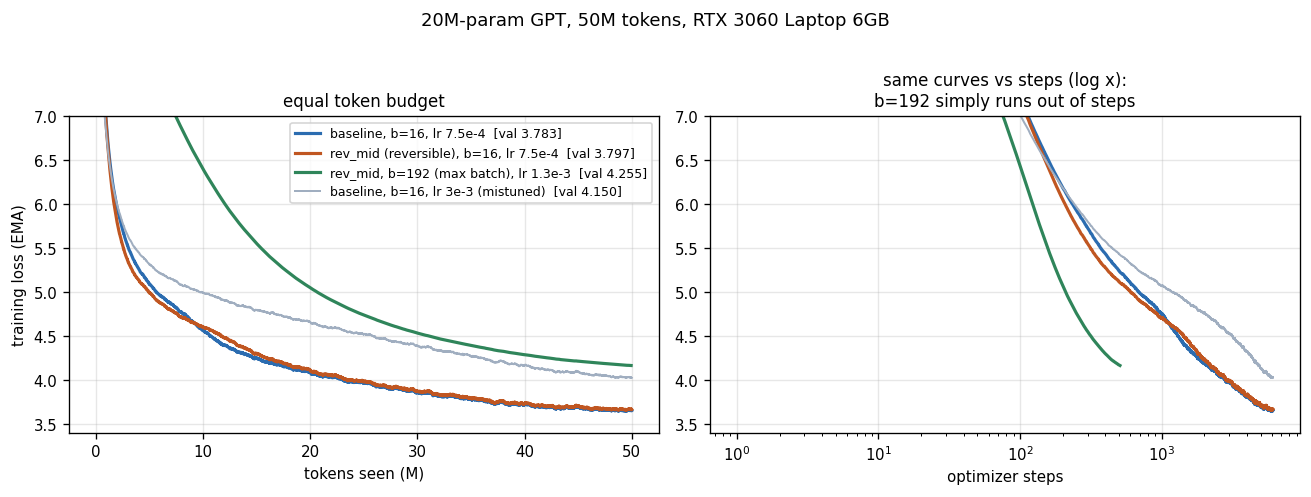

In [4]:
def ema(v, a=0.02):
    out = np.empty(len(v), dtype=float)
    acc = float(v[0])
    for i, x in enumerate(v):
        acc = (1 - a) * acc + a * float(x)
        out[i] = acc
    return out


specs = [
    ("r1b_baseline_b16_lr0.00075", "baseline, b=16, lr 7.5e-4", "#2b6cb0", 1.9),
    ("r2_rev_mid_b16", "rev_mid (reversible), b=16, lr 7.5e-4", "#c05621", 1.9),
    ("r3_rev_mid_b192_lr0.0013", "rev_mid, b=192 (max batch), lr 1.3e-3", "#2f855a", 1.9),
    ("r1_baseline_b16", "baseline, b=16, lr 3e-3 (mistuned)", "#a0aec0", 1.2),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, label, color, lw in specs:
    c, m = curve(name), metrics(name)
    toks = (c[:, 0] + 1) * m["batch"] * m["seq"] / 1e6
    y = ema(c[:, 1])
    axes[0].plot(toks, y, label=f"{label}  [val {m['final_val_loss']:.3f}]", color=color, lw=lw)
    axes[1].plot(c[:, 0] + 1, y, color=color, lw=lw)

axes[0].set_xlabel("tokens seen (M)"); axes[0].set_ylabel("training loss (EMA)")
axes[0].set_title("equal token budget")
axes[1].set_xlabel("optimizer steps"); axes[1].set_xscale("log")
axes[1].set_title("same curves vs steps (log x):\nb=192 simply runs out of steps")
for ax in axes:
    ax.set_ylim(3.4, 7.0)
axes[0].legend(fontsize=7.5)
fig.suptitle("20M-param GPT, 50M tokens, RTX 3060 Laptop 6GB", y=1.02)
fig.tight_layout()
plt.show()

## 3. Which reversible variant, and the LR sweep behind the choice

Two reversible stacks, both parameter-matched to the baseline:

- **`rev_euler`** — two-stream RevNet/Reformer coupling, `a += f(b); b += g(a)`: a semi-implicit
  **Euler** step. Attention only ever reads stream `b`, the MLP only reads `a`.
- **`rev_mid`** — single-stream **explicit midpoint / leapfrog**, `x_{i+1} = x_{i-1} + f_i(x_i)`
  with `x_{-1} = 0`. Symmetric, 2nd-order, and it reuses *the baseline's own full-width block
  verbatim* — only the skip connection moves.

Selection grid: 10M tokens, batch 16, every architecture bracketed on **both** sides of its optimum,
so this is best-vs-best rather than best-vs-mistuned.

val loss @ 10M tokens, batch 16 (AFTER the autocast-cache fix, see section 6)


arch,baseline,rev_euler,rev_mid,rev_mid_seed
lr,,,,
0.00020,5.1690,5.1468,NaN,NaN
0.00040,4.9115,4.9206,4.8526,NaN
0.00075,4.7538,4.9802,4.6716,4.6731
0.00150,4.9521,5.0811,4.8455,NaN
0.00300,5.1812,5.2686,NaN,NaN
0.00600,NaN,5.8937,NaN,NaN



best-vs-best:


,lr,val_loss,val_ppl
arch,,,
baseline,0.00075,4.7538,116.0
rev_euler,0.00040,4.9206,137.1
rev_mid,0.00075,4.6716,106.9
rev_mid_seed,0.00075,4.6731,107.0


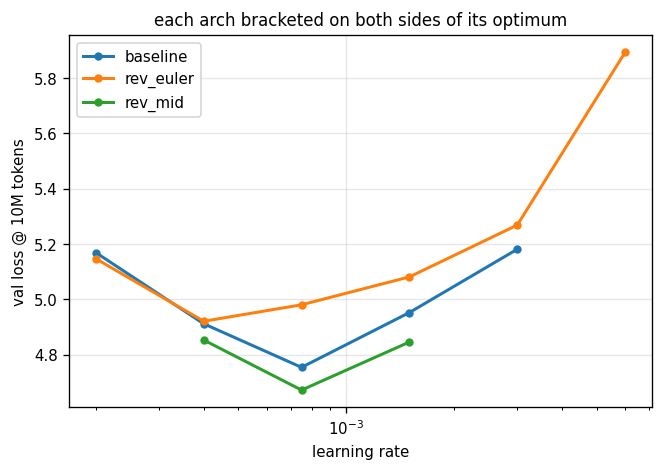

midpoint 4.6716  vs  euler 4.9206  vs  baseline 4.7538
-> rev_mid beats rev_euler by 0.249 nats and is the only variant that also beats
   the baseline (+0.082) at this horizon. Runs 2 and 3 use rev_mid.


In [5]:
sweep = []
for d in sorted(RUNS.iterdir()):
    if not re.match(r"^(s3_|s2_baseline)", d.name):
        continue
    m = metrics(d.name)
    if m:
        sweep.append({"arch": m["arch"], "lr": m["lr"], "val_loss": round(m["final_val_loss"], 4),
                      "val_ppl": round(m["val_ppl"], 1), "tok/s": round(m["tokens_per_s"] / 1e3, 1),
                      "peak_alloc_MB": round(m["peak_mem_allocated_mb"]), "run": d.name})
sweep_df = pd.DataFrame(sweep)
grid = sweep_df.pivot_table(index="lr", columns="arch", values="val_loss")
print("val loss @ 10M tokens, batch 16 (AFTER the autocast-cache fix, see section 6)")
display(grid)

best = sweep_df.loc[sweep_df.groupby("arch")["val_loss"].idxmin()].set_index("arch")
print("\nbest-vs-best:")
display(best[["lr", "val_loss", "val_ppl"]])

fig, ax = plt.subplots(figsize=(5.6, 4))
for arch, sub in sweep_df[sweep_df.arch.isin(["baseline", "rev_mid", "rev_euler"])].groupby("arch"):
    sub = sub.sort_values("lr")
    ax.plot(sub.lr, sub.val_loss, "o-", label=arch, lw=1.8, ms=4)
ax.set_xscale("log"); ax.set_xlabel("learning rate"); ax.set_ylabel("val loss @ 10M tokens")
ax.set_title("each arch bracketed on both sides of its optimum")
ax.legend()
fig.tight_layout(); plt.show()

vm, ve, vb = (best.loc[a, "val_loss"] for a in ("rev_mid", "rev_euler", "baseline"))
print(f"midpoint {vm:.4f}  vs  euler {ve:.4f}  vs  baseline {vb:.4f}")
print(f"-> rev_mid beats rev_euler by {ve-vm:.3f} nats and is the only variant that also beats")
print(f"   the baseline ({vb-vm:+.3f}) at this horizon. Runs 2 and 3 use rev_mid.")

### 3a. `rev_mid_seed`: the exact-`x0` variant

Reconstructing the *first* activation `x_0` by subtraction is catastrophically ill-conditioned
(§6): it is embedding-scale, but the backward recovers it by subtracting six blocks' worth of
accumulated residual. `rev_mid_seed` stores `x_0` instead — it is already an input to the reversible
`Function` — which restores block 0's gradient exactly, and changes the loss by nothing.

In [6]:
pair = sweep_df[(sweep_df.arch.isin(["rev_mid", "rev_mid_seed"])) & (sweep_df.lr == 7.5e-4)]
d = pair.set_index("arch")
display(d[["val_loss", "val_ppl", "peak_alloc_MB"]])
print(f"exact block-0 gradient costs "
      f"{d.loc['rev_mid_seed','peak_alloc_MB']-d.loc['rev_mid','peak_alloc_MB']:.0f} MB at batch 16 "
      f"and moves val loss by {d.loc['rev_mid_seed','val_loss']-d.loc['rev_mid','val_loss']:+.4f} nats "
      "-- i.e. noise.")
print("At batch 192 the same extra activation costs ~179 MB, which is enough to drop the max batch "
      "from 192 to 176.")

,val_loss,val_ppl,peak_alloc_MB
arch,,,
rev_mid,4.6716,106.9,1157
rev_mid_seed,4.6731,107.0,1176


exact block-0 gradient costs 19 MB at batch 16 and moves val loss by +0.0015 nats -- i.e. noise.
At batch 192 the same extra activation costs ~179 MB, which is enough to drop the max batch from 192 to 176.


## 4. Pushing to the maximum batch size

A batch only *fits* if **peak reserved < ~5120 MB free**. On Windows, exceeding it does **not** OOM:
the driver silently spills into shared system memory and throughput collapses — a worse failure than
a crash, because it looks like success.

| arch | max batch that fits | peak reserved there | first batch that spills |
|---|---|---|---|
| baseline | **56** | 4836 MB | 64 (5300 MB) |
| `rev_euler` | **192** | 4878 MB | 208 (5254 MB) |
| `rev_mid` | **192** | 5118 MB | 208 (5326 MB) |

(measured with `bench_batch.py` / `probe_mem.py` / `train.py --probe-batch`)

Reversibility buys a **3.4x larger batch** (56 -> 192) on the same card. But at a fixed 50M-token
budget the maximum batch is the wrong thing to spend it on — and the LR was swept to prove that is
not a tuning artifact.

In [7]:
b192 = []
for d2 in sorted(RUNS.glob("r3_rev_mid_b192_*")):
    m = metrics(d2.name)
    if m:
        b192.append({"lr": m["lr"], "steps": m["steps"], "val_loss": round(m["final_val_loss"], 4),
                     "val_ppl": round(m["val_ppl"], 1)})
b192_df = pd.DataFrame(b192).sort_values("lr").set_index("lr")
display(b192_df)

best192 = b192_df.val_loss.idxmin()
lr16 = b["lr"]
print(f"best b=192 LR: {best192:g}  (val {b192_df.val_loss.min():.4f})")
print(f"ratio to the b=16 optimum ({lr16:g}): {best192/lr16:.1f}x, for a "
      f"{r3['batch']/b['batch']:.0f}x larger batch")
print(f"sqrt-scaling would predict {lr16*np.sqrt(r3['batch']/b['batch']):.2e} -- it overshoots,")
print("because at 508 steps the run is nowhere near convergence and a big LR mostly costs early")
print("stability.\n")
print(f"steps: {b['steps']} -> {r3['steps']}  ({b['steps']/r3['steps']:.0f}x fewer)")
print(f"val loss: {b['final_val_loss']:.4f} (baseline b=16) vs {r3['final_val_loss']:.4f} (b=192) "
      f"-> {r3['final_val_loss']-b['final_val_loss']:+.3f} nats")
print("\nMax batch is worth having when memory is the binding constraint (longer seq, bigger model,")
print("avoiding gradient accumulation) -- not as a way to spend a fixed token budget faster.")

,steps,val_loss,val_ppl
lr,,,
0.00065,508,4.4691,87.3
0.00130,508,4.2545,70.4
0.00260,508,4.4020,81.6
0.00520,508,4.9890,146.8


best b=192 LR: 0.0013  (val 4.2545)
ratio to the b=16 optimum (0.00075): 1.7x, for a 12x larger batch
sqrt-scaling would predict 2.60e-03 -- it overshoots,
because at 508 steps the run is nowhere near convergence and a big LR mostly costs early
stability.

steps: 6103 -> 508  (12x fewer)
val loss: 3.7827 (baseline b=16) vs 4.2545 (b=192) -> +0.472 nats

Max batch is worth having when memory is the binding constraint (longer seq, bigger model,
avoiding gradient accumulation) -- not as a way to spend a fixed token budget faster.


## 5. Throughput, and the thermal confound on a laptop GPU

The per-run `tok/s` column in §1 is **not** a fair architecture comparison. Under sustained load this
chassis hits 88–89 °C and the driver's *SW thermal slowdown* governor drops the SM clock from
~1880 MHz to ~800–1000 MHz, roughly halving throughput mid-run. Whichever config happened to start
on a cooler card looks faster — identical configs measured anywhere from 28.3k to 40.5k tok/s.

Two independent fixes, from opposite ends of the thermal envelope, are in the repo:

1. `thermal_bench.py` — heat-soak to a plateau, *then* interleave the archs with continuous clock telemetry.
2. `repeat_guarded.py` + `train.py --thermal-guard` — start cool and measure only inside the boost regime,
   stopping the instant the governor engages.

,baseline,rev_mid,rev_euler
round 1,75178,48815,49922
round 2,74943,48172,48822
round 3,71891,46837,47432
round 4,70584,46007,46340
round 5,69434,44536,45566


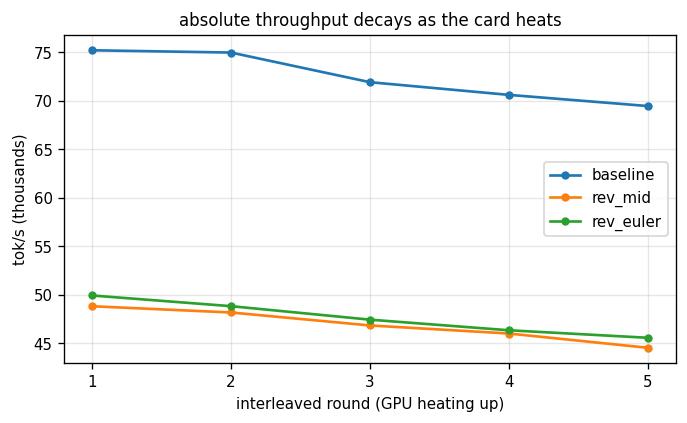

baseline drifts 75.2k -> 69.4k tok/s (8% lost) across 5 rounds of the SAME config.

ratio vs baseline, averaged over interleaved rounds (this part IS stable):
  baseline   1.000x
  rev_mid    1.545x
  rev_euler  1.521x


In [8]:
# raw cold->hot drift within a single interleaved A/B (speed_ab.py, 5 rounds, batch 16)
txt = (RUNS / "speed_ab_b16.txt").read_text()
sa = json.loads("{" + txt[txt.index('"rounds"'):])   # the saved dump is tail-truncated
rounds = sa["rounds"]
n_rounds = len(next(iter(rounds.values())))
rdf = pd.DataFrame(rounds, index=[f"round {i+1}" for i in range(n_rounds)])
display(rdf)

fig, ax = plt.subplots(figsize=(5.8, 3.6))
for k, v in rounds.items():
    ax.plot(range(1, len(v) + 1), np.array(v) / 1e3, "o-", label=k, lw=1.6, ms=4)
ax.set_xlabel("interleaved round (GPU heating up)"); ax.set_ylabel("tok/s (thousands)")
ax.set_title("absolute throughput decays as the card heats")
ax.set_xticks(range(1, n_rounds + 1)); ax.legend()
fig.tight_layout(); plt.show()

base0, baseN = rounds["baseline"][0], rounds["baseline"][-1]
print(f"baseline drifts {base0/1e3:.1f}k -> {baseN/1e3:.1f}k tok/s ({(1-baseN/base0)*100:.0f}% lost) "
      "across 5 rounds of the SAME config.")
print("\nratio vs baseline, averaged over interleaved rounds (this part IS stable):")
for k, v in sa["ratio_vs_baseline_mean"].items():
    print(f"  {k:10s} {v:.3f}x")

,samples,peak_MHz,first10_MHz,last50_MHz,median_MHz,max_temp_C,median_W
log,,,,,,,
clocks_final.log,457,1815.0,1429,860,765.0,89.0,57.0
clocks_postfix.log,1630,1950.0,1372,1444,915.0,89.0,59.7
clocks_r1_final.log,217,1882.0,1681,826,825.0,89.0,56.6
clocks_r2.log,55,1447.0,1224,889,877.0,89.0,58.6
clocks_run1.log,227,1867.0,1572,804,712.0,89.0,54.9
clocks_run2.log,226,1860.0,1552,779,712.0,89.0,54.9


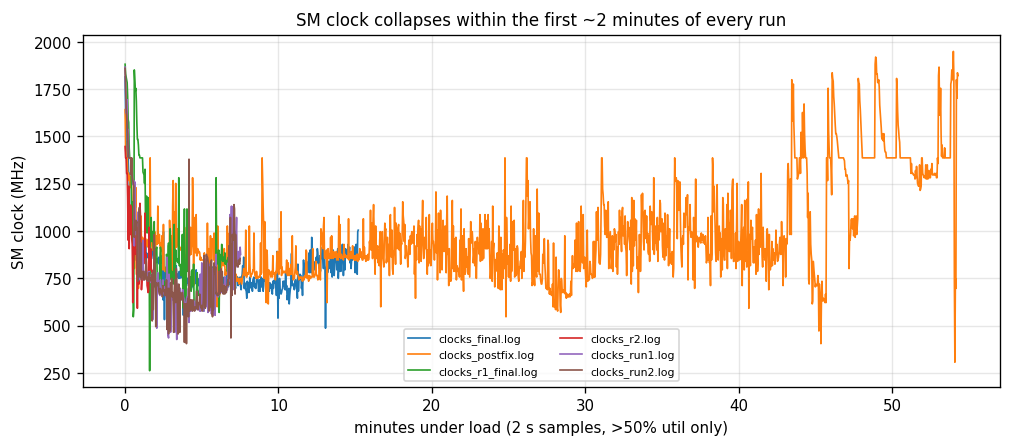

Limiter is the driver's SW thermal slowdown governor
(clocks_event_reasons.sw_thermal_slowdown=Active; HW thermal and power cap both inactive).
It is workload-pattern sensitive: a dense matmul stream holds 1387 MHz while the burstier
training loop settles at 800-1000 MHz.


In [9]:
def clock_stats(path):
    clk, tmp, pw = [], [], []
    for line in path.read_text().splitlines():
        parts = [s.strip() for s in line.split(",")]
        if len(parts) < 4 or "%" not in parts[3]:
            continue
        if float(parts[3].replace("%", "")) < 50:      # only while the GPU is actually training
            continue
        tmp.append(float(parts[0]))
        clk.append(float(parts[1].replace("MHz", "")))
        pw.append(float(parts[2].replace("W", "")))
    if not clk:
        return None, None
    clk = np.array(clk)
    return {"log": path.name, "samples": len(clk), "peak_MHz": clk.max(),
            "first10_MHz": round(clk[:10].mean()), "last50_MHz": round(clk[-50:].mean()),
            "median_MHz": float(np.median(clk)), "max_temp_C": max(tmp),
            "median_W": round(float(np.median(pw)), 1)}, clk


stats, series = [], {}
for p in sorted(RUNS.glob("clocks_*.log")):
    s, clk = clock_stats(p)
    if s:
        stats.append(s)
        series[p.name] = clk
display(pd.DataFrame(stats).set_index("log"))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
for name, clk in series.items():
    ax.plot(np.arange(len(clk)) * 2 / 60, clk, lw=1, label=name)
ax.set_xlabel("minutes under load (2 s samples, >50% util only)"); ax.set_ylabel("SM clock (MHz)")
ax.set_title("SM clock collapses within the first ~2 minutes of every run")
ax.legend(fontsize=6.5, ncol=2)
fig.tight_layout(); plt.show()

print("Limiter is the driver's SW thermal slowdown governor")
print("(clocks_event_reasons.sw_thermal_slowdown=Active; HW thermal and power cap both inactive).")
print("It is workload-pattern sensitive: a dense matmul stream holds 1387 MHz while the burstier")
print("training loop settles at 800-1000 MHz.")

### 5a. Steady-state (heat-soaked) throughput — `thermal_bench.py`

Soaking to the 88 °C plateau first and only then interleaving collapses round-to-round spread from
~8% to <0.5%. At a pinned 1387 MHz:

| arch | tok/s @1387 MHz | tok/s per MHz | vs baseline |
|---|---|---|---|
| baseline | **63.7k** | 45.9 | 1.00x |
| `rev_mid` | **41.7k** | 30.1 | **1.53x slower** |
| `rev_euler` | **42.5k** | 30.7 | **1.50x slower** |

`tok/s per MHz` is thermal-state invariant, which makes it the fair basis for comparison here.

### 5b. Independent cross-check — the boost-regime guard (`repeat_guarded.py`)

The opposite approach: start from a cool card (≤65 °C) and train only while it is still boosting,
stopping the moment the governor engages (`sw_thermal_slowdown` Active, or ≥87 °C, two consecutive
2 s samples). Verified before use — the guard tripped at 87 °C / 1762 MHz while still drawing 114 W,
i.e. at throttle *onset*, before any clock collapse. This is a measurement-regime guard, not a
hardware safety device; the card's own protection sits near 93 °C and was never approached.

In [10]:
g = pd.DataFrame(json.loads((RUNS / "guarded_repeat_summary.json").read_text()))
g["boost_ktok_s"] = (g.tok_s_untill_stop / 1e3).round(1)
display(g[["run", "arch", "batch", "status", "start_temp_c", "steps_done", "tokens_done",
           "boost_ktok_s", "min_clk_mhz", "max_temp_c", "wall_s", "stopped_reason"]]
        .set_index("run"))

throttled = {"g1_baseline_b16": b, "g2_rev_mid_b16": r, "g3_rev_mid_b192": r3}
cmp_rows = []
for _, row in g.iterrows():
    m = throttled[row["run"]]
    cmp_rows.append({"run": row["run"],
                     "boost tok/s": f"{row.tok_s_untill_stop/1e3:.1f}k",
                     "throttled tok/s (S1)": f"{m['tokens_per_s']/1e3:.1f}k",
                     "gain": round(row.tok_s_untill_stop / m["tokens_per_s"], 2),
                     "tokens before trip": f"{row.tokens_done/1e6:.2f}M",
                     "% of 50M": round(row.tokens_done / 50e6 * 100, 1)})
display(pd.DataFrame(cmp_rows).set_index("run"))

gb = g.set_index("run")
boost_cost = gb.loc["g1_baseline_b16", "tok_s_untill_stop"] / gb.loc["g2_rev_mid_b16", "tok_s_untill_stop"]
print("cost of reversibility, measured twice, in opposite thermal regimes:")
print(f"  heat-soak   (throttled,   1387 MHz): 1.53x   [thermal_bench.py]")
print(f"  boost guard (unthrottled, >=1702 MHz): {boost_cost:.2f}x   [repeat_guarded.py]")
print("\nThe two methods agree to within ~1%: the ~1.5x cost is a property of the code, not of when a")
print("run happened to start. (Theory alone predicts only ~1.33x extra forward; the gap comes from the")
print("backward re-running each block under torch.autograd.grad with a fresh autocast cast per block,")
print("which does not fuse as well as a plain backward.)")
print(f"\nThe batch-192 speedup reproduces too: "
      f"{gb.loc['g3_rev_mid_b192','tok_s_untill_stop']/gb.loc['g2_rev_mid_b16','tok_s_untill_stop']:.2f}x "
      f"over b=16 in boost vs {r3['tokens_per_s']/r['tokens_per_s']:.2f}x throttled.")
print("\nAlso proved: the 50M-token experiment CANNOT be run unthrottled on this machine -- the boost")
print(f"regime lasts {g.wall_s.min():.0f}-{g.wall_s.max():.0f} s, i.e. at most "
      f"{g.tokens_done.max()/50e6*100:.1f}% of one run. Sustaining it means")
print("dissipating 114 W against the ~59 W this chassis holds at its 89 C ceiling -- a ~2x cooling")
print("deficit that a cooling pad's typical 3-8 C does not bridge. The throttled numbers in section 1")
print("are the real sustained performance of this hardware; the guard is a throughput probe, not a")
print("training mode, and its loss values (EMA 5.8-8.7 at 1-2M tokens) are meaningless. Caveat: these")
print("runs are 12-239 steps, so tok/s carries some warm-up amortization -- the b=192 entry timed only")
print("7 steps and is the noisiest.")

,arch,batch,status,start_temp_c,steps_done,tokens_done,boost_ktok_s,min_clk_mhz,max_temp_c,wall_s,stopped_reason
run,,,,,,,,,,,
g1_baseline_b16,baseline,16,STOPPED_THERMAL,64.0,239,1957888,74.8,1702.0,87.0,26.655410,throttled: 86C 1747MHz sw_thermal_slowdown=True
g2_rev_mid_b16,rev_mid,16,STOPPED_THERMAL,65.0,133,1089536,49.2,1702.0,87.0,22.623312,throttled: 87C 1762MHz sw_thermal_slowdown=True
g3_rev_mid_b192,rev_mid,192,STOPPED_THERMAL,65.0,12,1179648,61.5,1702.0,87.0,22.824329,throttled: 86C 1717MHz sw_thermal_slowdown=True


,boost tok/s,throttled tok/s (S1),gain,tokens before trip,% of 50M
run,,,,,
g1_baseline_b16,74.8k,40.5k,1.85,1.96M,3.9
g2_rev_mid_b16,49.2k,28.8k,1.71,1.09M,2.2
g3_rev_mid_b192,61.5k,35.2k,1.75,1.18M,2.4


cost of reversibility, measured twice, in opposite thermal regimes:
  heat-soak   (throttled,   1387 MHz): 1.53x   [thermal_bench.py]
  boost guard (unthrottled, >=1702 MHz): 1.52x   [repeat_guarded.py]

The two methods agree to within ~1%: the ~1.5x cost is a property of the code, not of when a
run happened to start. (Theory alone predicts only ~1.33x extra forward; the gap comes from the
backward re-running each block under torch.autograd.grad with a fresh autocast cast per block,
which does not fuse as well as a plain backward.)

The batch-192 speedup reproduces too: 1.25x over b=16 in boost vs 1.22x throttled.

Also proved: the 50M-token experiment CANNOT be run unthrottled on this machine -- the boost
regime lasts 23-27 s, i.e. at most 3.9% of one run. Sustaining it means
dissipating 114 W against the ~59 W this chassis holds at its 89 C ceiling -- a ~2x cooling
deficit that a cooling pad's typical 3-8 C does not bridge. The throttled numbers in section 1
are the real sustained pe

## 6. Correctness of the reversible backward

Two separate checks, because they catch different classes of bug:

- **`gradcheck.py`** — fp32 on CPU, custom reversible `Function` vs a store-everything autograd
  reference, asserting `max_rel_grad_err < 1e-5`. Run it in
  [`03_gradient_correctness.ipynb`](03_gradient_correctness.ipynb).
- **`revcheck.py`** — the same comparison **on GPU, in bf16, with trained weights**, which is the
  regime training actually runs in. Its output is committed as `runs/revcheck_*.json`.

### The bug that made the first round of results worthless

Under `torch.autocast`, the bf16 copy of each weight is **cached**. The reversible backward
recomputes blocks inside `torch.autograd.grad`, but the forward ran under `no_grad()` — so the cached
bf16 copy carries **no `grad_fn`**, the recompute cannot reach the fp32 parameter, and
`allow_unused=True` returns `None` for **every Linear weight in every block**. All attention and MLP
matrices were **frozen at initialization**; only LayerNorm gains and the embedding trained. Loss still
fell from 7.5 to 4.9, so nothing looked wrong — and `gradcheck.py` kept passing at 6e-7, because it
runs fp32 on CPU, where there is no weight cache.

**Correctness tests must run in the precision and on the device you actually train in.**

The fix is one context manager (`model.py`), plus `_require_all_grads`, which now raises instead of
silently accepting a `None` gradient for any block parameter:

```python
with torch.autocast("cuda", dtype=dtype, cache_enabled=False), torch.enable_grad():
    ...
```

The tell was a **flat LR response** — a model that barely cares about its learning rate over a 4x
range is usually not training.

In [11]:
pre = sorted(d2.name for d2 in RUNS.iterdir() if d2.name.startswith("buggy_")
             and (d2 / "metrics.json").exists())
rows = []
for n in pre:
    m = metrics(n)
    rows.append({"run": n, "arch": m["arch"], "lr": m["lr"], "tokens": f"{m['tokens']/1e6:.0f}M",
                 "val_loss": round(m["final_val_loss"], 4)})
buggy_df = pd.DataFrame(rows).set_index("run")
print("SUPERSEDED runs -- block weights were frozen by the autocast weight cache:")
display(buggy_df)

sub = buggy_df[buggy_df.arch == "rev_mid"].sort_values("lr")
print(f"broken rev_mid, val loss over a {sub.lr.max()/sub.lr.min():.0f}x LR range "
      f"({sub.lr.min():g} -> {sub.lr.max():g}): spread {sub.val_loss.max()-sub.val_loss.min():.4f} "
      "nats -- essentially flat.")
fixed = sweep_df[sweep_df.arch == "rev_mid"].sort_values("lr")
print(f"fixed   rev_mid, over a {fixed.lr.max()/fixed.lr.min():.0f}x LR range: spread "
      f"{fixed.val_loss.max()-fixed.val_loss.min():.4f} nats, clean interior minimum at lr "
      f"{fixed.loc[fixed.val_loss.idxmin(),'lr']:g}.")

bug_e = buggy_df[buggy_df.arch == "rev_euler"].val_loss.min()
bug_m = buggy_df[buggy_df.arch == "rev_mid"].val_loss.min()
fix_e = sweep_df[sweep_df.arch == "rev_euler"].val_loss.min()
fix_m = sweep_df[sweep_df.arch == "rev_mid"].val_loss.min()
print(f"\nit also flipped the variant verdict:")
print(f"  broken: rev_euler {bug_e:.4f} vs rev_mid {bug_m:.4f}  -> euler looked better")
print(f"  fixed : rev_euler {fix_e:.4f} vs rev_mid {fix_m:.4f}  -> midpoint wins decisively")

SUPERSEDED runs -- block weights were frozen by the autocast weight cache:


,arch,lr,tokens,val_loss
run,,,,
buggy_r2_rev_euler_b16,rev_euler,0.0060,50M,5.0565
buggy_r3_rev_euler_b192_lr1.2e-2,rev_euler,0.0120,50M,5.1193
buggy_r3_rev_euler_b192_lr2.4e-2,rev_euler,0.0240,50M,5.0975
buggy_s2_rev_euler_0.0015,rev_euler,0.0015,10M,5.3073
buggy_s2_rev_euler_0.003,rev_euler,0.0030,10M,5.2715
buggy_s2_rev_euler_0.006,rev_euler,0.0060,10M,5.2674
buggy_s2_rev_mid_0.0015,rev_mid,0.0015,10M,5.3044
buggy_s2_rev_mid_0.003,rev_mid,0.0030,10M,5.2830
buggy_s2_rev_mid_0.006,rev_mid,0.0060,10M,5.2795


broken rev_mid, val loss over a 4x LR range (0.0015 -> 0.006): spread 0.0249 nats -- essentially flat.
fixed   rev_mid, over a 4x LR range: spread 0.1810 nats, clean interior minimum at lr 0.00075.

it also flipped the variant verdict:
  broken: rev_euler 5.0565 vs rev_mid 5.2795  -> euler looked better
  fixed : rev_euler 4.9206 vs rev_mid 4.6716  -> midpoint wins decisively


In [12]:
# GPU/bf16 reconstruction drift with TRAINED weights (runs/revcheck_*.json)
def recon_items(d2):
    """Label the reconstruction-error entries. Both schemas are ordered from the input side
    outward, so entry 0 is the activation closest to the embedding."""
    if "recon_rel_err_by_layer" in d2:                 # newer revcheck.py: already labelled
        return list(d2["recon_rel_err_by_layer"].items())
    vals = d2["recon_rel_err_per_layer"]
    if d2["arch"].startswith("rev_euler"):
        return [(f"(a,b) entering block {i}", v) for i, v in enumerate(vals)]
    # leapfrog keeps x_{-1} (identically zero) first, then x_0 .. x_{N-2}
    names = ["x_-1 (zero seed)"] + [f"x_{i}" for i in range(len(vals) - 1)]
    return list(zip(names, vals))


for p in sorted(RUNS.glob("revcheck_*.json")):
    txt = p.read_text()
    d2 = json.loads(txt[txt.index("{"):])
    print(f"--- {p.name} ---")
    print(f"  arch {d2['arch']}, trained_steps {d2['trained_steps']}, bf16 {d2['bf16']}")
    print(f"  loss (reversible) {d2['loss_rev']:.6f}  vs reference {d2['loss_ref']:.6f}  "
          "-> forward is identical")
    print("  reconstruction rel err, embedding side first:")
    for name, e in recon_items(d2):
        if e is None:
            print(f"      {name:26s} undefined (reference is all-zero)")
        else:
            print(f"      {name:26s} {e:.3e}" + ("   <-- unusable" if e > 1.0 else ""))
    print(f"  worst param: {d2['worst_param']}   max grad rel err {d2['max_grad_rel_err']:.3g}")
    print(f"  min grad cosine similarity vs true grad: {d2['min_grad_cosine_sim']:.4f}\n")

print("x_1..x_4 reconstruct to ~1e-3 or better. The outlier, by orders of magnitude, is x_0 -- the")
print("first activation: rel err 87 with trained weights (and 0.065 at init, where everything is")
print("still small). x_-1 is the all-zero seed, so a ratio against it is meaningless, not a finding.")
print("")
print("The cause is catastrophic cancellation, not rounding: x_0 is embedding-scale but is recovered")
print("by subtracting six blocks' worth of accumulated residual. It shows up in the gradients as a")
print("collapse of cosine similarity with trained weights (min 0.15 here, 0.9997 at init); REPORT.md")
print("section 5b's per-block breakdown of the same effect puts block 0 at 0.054 and blocks 1-5 at")
print("0.998-1.000, i.e. the damage is confined to the first block. Redoing the check in fp32 only")
print("lifts block 0 to ~0.24 -- precision does not fix an ill-conditioned subtraction.")
print("")
print("Storing x_0 instead (rev_mid_seed, section 3a) restores it exactly -- and changes the loss by")
print("nothing, because at 6 layers the first block does little enough work that a garbage gradient")
print("there is harmless. I would expect that to stop being true with depth.")

--- revcheck_euler_trained.json ---
  arch rev_euler, trained_steps 300, bf16 True
  loss (reversible) 6.608437  vs reference 6.608437  -> forward is identical
  reconstruction rel err, embedding side first:
      (a,b) entering block 0     3.175e+03   <-- unusable
      (a,b) entering block 1     2.564e-03
      (a,b) entering block 2     1.786e-03
      (a,b) entering block 3     1.418e-03
      (a,b) entering block 4     6.064e-04
      (a,b) entering block 5     4.525e-04
  worst param: blocks.0.attn.qkv.weight   max grad rel err 1.9
  min grad cosine similarity vs true grad: 0.7543

--- revcheck_mid_init.json ---
  arch rev_mid, trained_steps 0, bf16 True
  loss (reversible) 9.092338  vs reference 9.092338  -> forward is identical
  reconstruction rel err, embedding side first:
      x_-1 (zero seed)           2.045e+10   <-- unusable
      x_0                        6.468e-02
      x_1                        1.215e-02
      x_2                        4.143e-03
      x_3          

## 7. Windows-specific memory traps

- **No OOM at the ceiling.** Past ~5120 MB reserved the driver falls back to shared system memory
  instead of raising. Batch 256 "succeeded" at 6382 MB reserved with throughput down ~20%. Check
  `max_memory_reserved` against `torch.cuda.mem_get_info()` rather than trusting the absence of an
  exception.
- **`expandable_segments:True` is a no-op on Windows.** It is the usual remedy for the ~1.2x gap
  between allocated and reserved; here it changed reserved by exactly 0 MB at every batch. That
  fragmentation gap is what actually caps the batch at 192 — allocated is only 4502 MB.

In [13]:
print("allocated vs reserved (the gap is what really caps the batch):")
for label, name in MAIN.items():
    m = metrics(name)
    a, rv = m["peak_mem_allocated_mb"], m["peak_mem_reserved_mb"]
    print(f"  {label:40s} alloc {a:7.0f} MB   reserved {rv:7.0f} MB   gap {rv/a:.2f}x")
print("\n~5120 MB is all that is actually free on this 6 GB card (Windows holds ~1 GB).")
print(f"run 3 sits at {r3['peak_mem_reserved_mb']:.0f} MB reserved -- right against the wall, while "
      f"only {r3['peak_mem_allocated_mb']:.0f} MB is live tensor data.")

allocated vs reserved (the gap is what really caps the batch):
  1. baseline b=16                         alloc    2130 MB   reserved    2348 MB   gap 1.10x
  2. rev_mid b=16                          alloc    1157 MB   reserved    1482 MB   gap 1.28x
  3. rev_mid b=192 (max)                   alloc    4502 MB   reserved    5118 MB   gap 1.14x
  (ref) baseline b=16, mistuned lr 3e-3    alloc    2130 MB   reserved    2348 MB   gap 1.10x

~5120 MB is all that is actually free on this 6 GB card (Windows holds ~1 GB).
run 3 sits at 5118 MB reserved -- right against the wall, while only 4502 MB is live tensor data.


## Conclusions

1. **Reversibility is free, accuracy-wise, at this scale.** Matched params, matched 50M-token budget,
   each at its own tuned LR: 3.797 vs 3.783 val loss — a 0.014-nat gap, 1.4% perplexity.
2. **It cuts activation memory ~2.2x** (1.84x of total peak allocated) and raises the largest batch
   that fits 6 GB from 56 to 192 (**3.4x**).
3. **It costs ~1.5x wall-clock**, confirmed by two methods in opposite thermal regimes (1.53x
   heat-soaked, 1.52x in boost) — more than the ~1.33x theory predicts, because the recompute does not
   fuse as well as a plain backward.
4. **Midpoint (leapfrog) beats the two-stream Euler coupling** clearly (4.672 vs 4.921 @10M tokens) and
   is the only variant that also beats the baseline at that horizon.
5. **Max batch is not how you spend a fixed token budget.** 508 steps instead of 6103 costs 0.46 nats,
   and the LR sweep shows that is not mistuning. Big batches are for when memory is the binding
   constraint.
6. **Tuning mattered ~26x more than the architecture** (0.37 nats from re-tuning the baseline alone).
7. **The autocast weight cache silently froze every block weight** in the first round of results, and
   an fp32/CPU gradcheck could not see it. Test in the precision and on the device you train in — and
   treat a flat LR response as a bug signal.
8. **Reconstructing the first activation is ill-conditioned**, exactly as the residual scales predict —
   but fixing it changes nothing at 6 layers.